# Task 2: Time Series Forecasting Models

## Objectives

- Prepare the time series data for forecasting.
- Build and evaluate ARIMA/SARIMA models.
- Build and evaluate an LSTM model.
- Compare forecasting performance using MAE, RMSE, and MAPE.
- Select the best model for future forecasting.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time Series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Auto ARIMA
from pmdarima import auto_arima

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
import yfinance as yf

In [6]:
df = yf.download("TSLA", start="2015-01-01", end="2026-06-30")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [7]:
df = df[['Close']].copy()

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

Price,Close
Ticker,TSLA
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


In [9]:
print(df.columns)

MultiIndex([('Close', 'TSLA')],
           names=['Price', 'Ticker'])


In [10]:
df.columns = ['_'.join(col) for col in df.columns]
print(df.columns)

Index(['Close_TSLA'], dtype='str')


In [12]:
tsla = df['Close_TSLA']

In [13]:
tsla = tsla.dropna()
tsla = tsla.sort_index()

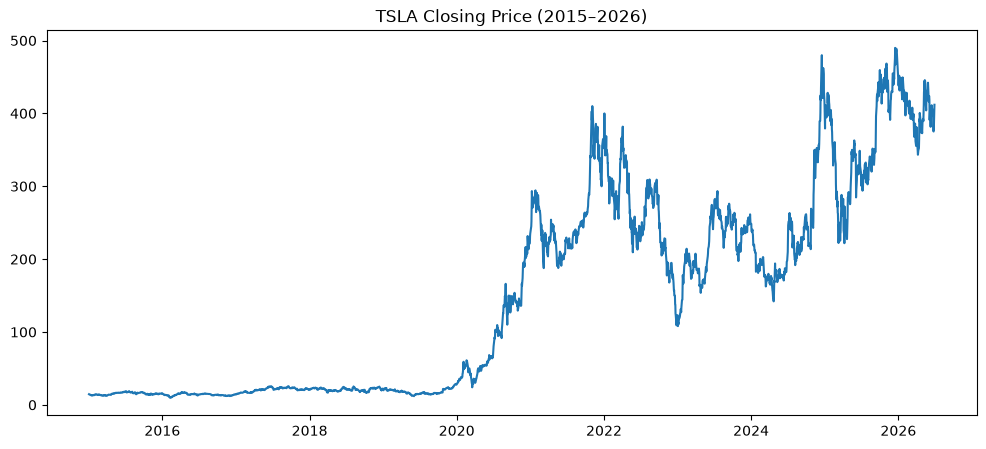

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tsla)
plt.title("TSLA Closing Price (2015–2026)")
plt.show()

In [15]:
train_size = int(len(tsla) * 0.8)

train = tsla.iloc[:train_size]
test = tsla.iloc[train_size:]

print(len(train), len(test))

2310 578


In [16]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=14614.905, Time=6.01 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14610.010, Time=0.25 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14610.292, Time=2.30 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14610.329, Time=0.53 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14608.366, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14610.926, Time=2.15 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 11.528 seconds


In [17]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=auto_model.order)
model_fit = model.fit()

In [18]:
arima_pred = model_fit.forecast(steps=len(test))
arima_pred = pd.Series(arima_pred, index=test.index)

In [19]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(tsla.values.reshape(-1,1))

In [20]:
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-60:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)

In [21]:
X = X.reshape((X.shape[0], X.shape[1], 1))

In [22]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60,1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

In [24]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 30s 138ms/step - loss: 0.0054
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 8.4411e-04
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - loss: 7.4258e-04
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - loss: 6.3610e-04
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - loss: 5.9185e-04
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - loss: 5.1388e-04
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - loss: 5.3294e-04
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - loss: 4.5051e-04
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - loss: 4.2125e-04
Epoch 10/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - loss: 4.0956e-04


In [25]:
lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [27]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

In [28]:
lstm_mae, lstm_rmse, lstm_mape = evaluate(y_test_actual, lstm_pred)

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)

LSTM MAE: 14.113525956763818
LSTM RMSE: 18.226730419744797
LSTM MAPE: 4.497509513740216


In [29]:
arima_pred
test

Date
2024-03-08    175.339996
2024-03-11    177.770004
2024-03-12    177.539993
2024-03-13    169.479996
2024-03-14    162.500000
                 ...    
2026-06-23    381.609985
2026-06-24    375.529999
2026-06-25    375.119995
2026-06-26    379.709991
2026-06-29    411.839996
Name: Close_TSLA, Length: 578, dtype: float64

In [31]:
print(test.isna().sum())
print(arima_pred.isna().sum())

0
578


In [32]:
test_clean = test.dropna()
arima_pred_clean = arima_pred.dropna()

In [33]:
min_len = min(len(test_clean), len(arima_pred_clean))

test_clean = test_clean.iloc[:min_len]
arima_pred_clean = arima_pred_clean.iloc[:min_len]

In [35]:
test.dropna()
arima_pred.dropna()

Series([], Name: predicted_mean, dtype: float64)

In [36]:
df_compare = pd.concat([test, arima_pred], axis=1)
df_compare.columns = ['actual', 'predicted']
df_compare = df_compare.dropna()

In [37]:
y_true = df_compare['actual'].values
y_pred = df_compare['predicted'].values

In [39]:
print("Train:", len(train))
print("Test:", len(test))
print("ARIMA prediction:", len(arima_pred))

Train: 2310
Test: 578
ARIMA prediction: 578


In [40]:
print(arima_pred.head())
print(arima_pred.tail())

Date
2024-03-08   NaN
2024-03-11   NaN
2024-03-12   NaN
2024-03-13   NaN
2024-03-14   NaN
Name: predicted_mean, dtype: float64
Date
2026-06-23   NaN
2026-06-24   NaN
2026-06-25   NaN
2026-06-26   NaN
2026-06-29   NaN
Name: predicted_mean, dtype: float64


In [41]:
print("NaNs in test:", test.isna().sum())
print("NaNs in arima_pred:", arima_pred.isna().sum())

NaNs in test: 0
NaNs in arima_pred: 578


In [42]:
print("Test index:")
print(test.index[:5])

print("Prediction index:")
print(arima_pred.index[:5])

Test index:
DatetimeIndex(['2024-03-08', '2024-03-11', '2024-03-12', '2024-03-13',
               '2024-03-14'],
              dtype='datetime64[s]', name='Date', freq=None)
Prediction index:
DatetimeIndex(['2024-03-08', '2024-03-11', '2024-03-12', '2024-03-13',
               '2024-03-14'],
              dtype='datetime64[s]', name='Date', freq=None)


In [43]:
print(type(test))
print(type(arima_pred))

<class 'pandas.Series'>
<class 'pandas.Series'>


In [44]:
forecast = model_fit.forecast(steps=len(test))

print(forecast.head())
print(forecast.isna().sum())

2310    178.649994
2311    178.649994
2312    178.649994
2313    178.649994
2314    178.649994
Name: predicted_mean, dtype: float64
0


In [45]:
arima_pred = pd.Series(forecast.values, index=test.index)

In [46]:
arima_mae, arima_rmse, arima_mape = evaluate(
    test.values,
    arima_pred.values
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

ARIMA MAE: 147.1856104708873
ARIMA RMSE: 173.42736057091875
ARIMA MAPE: 39.96120485354115


In [47]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Close_TSLA   No. Observations:                 2310
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -7303.183
Date:                Mon, 06 Jul 2026   AIC                          14608.366
Time:                        17:02:28   BIC                          14614.110
Sample:                             0   HQIC                         14610.460
                               - 2310                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        32.7199      0.368     88.861      0.000      31.998      33.442
Ljung-Box (L1) (Q):                   1.72   Jarque-Bera (JB):             13166.89
Prob(Q):                              0.19   Pr

In [48]:
forecast = model_fit.forecast(steps=len(test))
print(forecast.head())
print("NaNs:", forecast.isna().sum())

2310    178.649994
2311    178.649994
2312    178.649994
2313    178.649994
2314    178.649994
Name: predicted_mean, dtype: float64
NaNs: 0


In [49]:
arima_pred = pd.Series(forecast.values, index=test.index)

In [50]:
arima_mae, arima_rmse, arima_mape = evaluate(
    test.values,
    arima_pred.values
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

ARIMA MAE: 147.1856104708873
ARIMA RMSE: 173.42736057091875
ARIMA MAPE: 39.96120485354115


In [51]:
results = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [arima_mae, lstm_mae],
    "RMSE": [arima_rmse, lstm_rmse],
    "MAPE": [arima_mape, lstm_mape]
})

results

,Model,MAE,RMSE,MAPE
0,ARIMA,147.185610,173.427361,39.961205
1,LSTM,14.113526,18.226730,4.497510


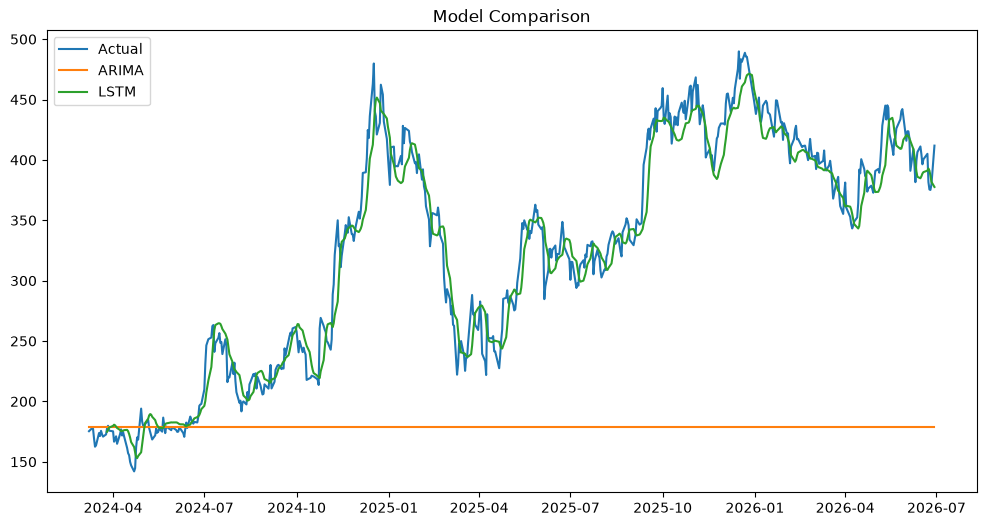

In [52]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA")
plt.plot(test.index[-len(lstm_pred):], lstm_pred, label="LSTM")

plt.legend()
plt.title("Model Comparison")
plt.show()